# DESI QSO Simulations

In [1]:
import fitsio
import numpy as np
import healpy as hp
import pandas as pd
import seaborn as sns
from astropy.table import Table, vstack, MaskedColumn
import matplotlib.pyplot as plt
%matplotlib inline

from Simulation.simulMap import *
from Simulation.fitMap import *
from Simulation.lumMag_sampling import *
from Simulation.mappers import DensityMapper, FracCovMapper

In [2]:
nside = 128
npix= hp.nside2npix(nside)
area_deg2 = hp.nside2pixarea(nside, degrees=True)
print("Number of pixels = {}".format(npix))
print("Surface of a pixel = {} deg^2".format(area_deg2))

Number of pixels = 196608
Surface of a pixel = 0.2098234113027917 deg^2


In [3]:
unit_size = 18
DensityMapper._settingsPlot['unit_size'] = unit_size
FracCovMapper._settingsPlot['unit_size'] = unit_size

## FRACCOV

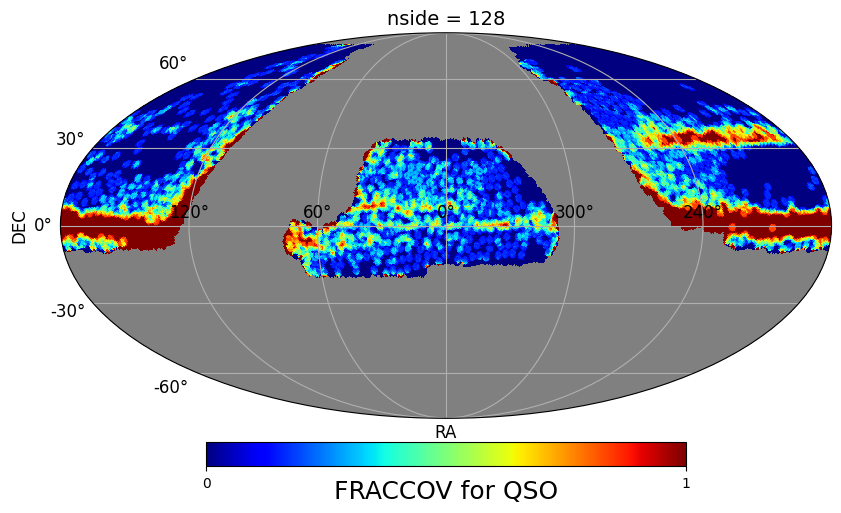

In [4]:
#File name:
DIR = "data/Data DESI/"
FILE_DR1 = DIR + "dr1-main-dark.fits"

sources="QSO"

outputDIR = DIR + f"DESI Figures/DESI DR1 {sources}/" #to save figures
output_path_data = outputDIR + f"DESI_DR1_{sources}_Data/" #common suffix to every figures
output_path_Simu = outputDIR + f"DESI_DR1_{sources}_Simul/"
suffix_data = f"DESI_DR1_{sources}_Density_map_"
suffix_Simu = f"DESI_DR1_{sources}_Simul_Density_map_"

#Reading file:
DR1_Mapper = FracCovMapper.read(FILE_DR1, nest=True)
DR1_Mapper.get_nside(nside)
DR1_Mapper._set_suffixTextPlot(unit = sources) #to customize the unit of plots.
DR1_Mapper.plot(use_map = "nside", title = f"nside = {DR1_Mapper.nside}")

## Density

### From DESI data

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.492e+06 (χ²/ndof = 12.7) │              Nfcn = 378              │
│ EDM = 4.63e-06 (Goal: 0.0002)    │           time = 12.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │   79.93   │   0.05    │   -0.05    │    0.05    │    0    │         │       │
│ 1 │ A    │  0.6125   │  0.0013   │  -0.0013   │   0.0013   │    0    │    1    │       │
│ 2 │ ra   │  186.22   │   0.24    │   -0.24    │    0.24    │    0    │   360   │       │
│ 3 │ dec  │  -70.06   │   0.06    │   -0.06    │    0.06    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.05   │   0.05    │  -0.0013  │  0.0013   │   -0.24   │   0.24    │   -0.06   │   0.06    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │  0.00271  34.2e-6   0.0005  -0.0009 │
│   A │  34.2e-6 1.62e-06  39.1e-6 -18.6e-6 │
│  ra │   0.0005  39.1e-6   0.0571   -0.000 │
│ dec │  -0.0009 -18.6e-6   -0.000   0.0039 │
└─────┴─────────────────────────────────────┘

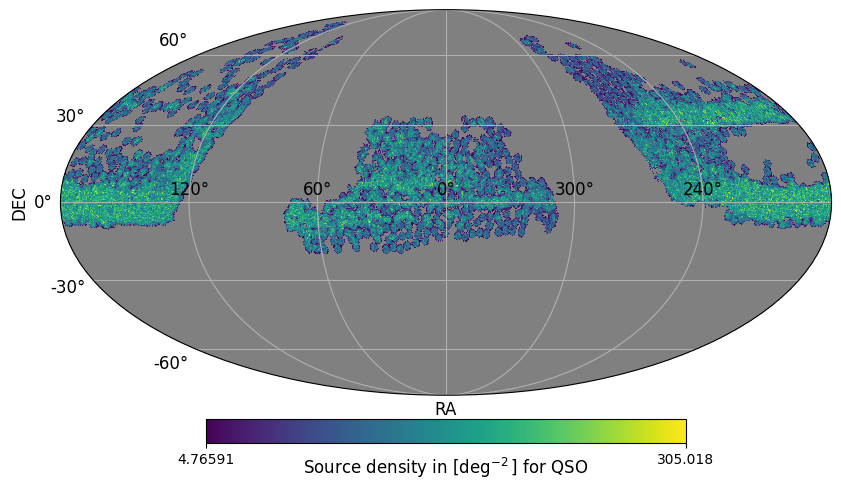

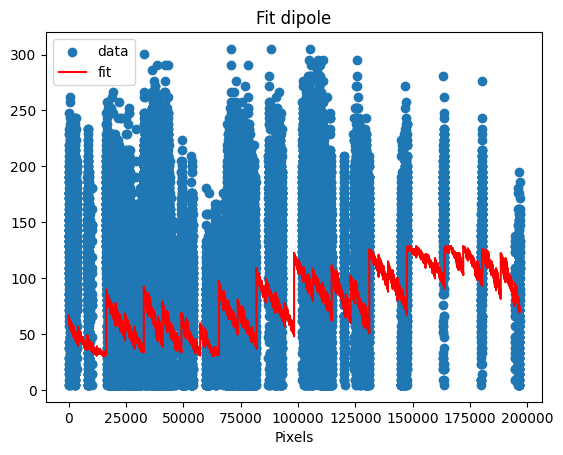

In [4]:
#File names:
FILE_NGC = DIR + "QSO_NGC_clustering.dat.fits"
FILE_SGC = DIR + "QSO_SGC_clustering.dat.fits"

#Reading files:
NGC_Mapper = DensityMapper.read(FILE_NGC, nside=nside, nest=True)
SGC_Mapper = DensityMapper.read(FILE_SGC, nside=nside, nest=True)
ALL_Mapper = NGC_Mapper.add(SGC_Mapper)
ALL_Mapper._set_suffixTextPlot(unit = sources) #to customize the unit of plots.
ALL_Mapper.set_mask()
# ALL_Mapper.plot("Masked")
# get_savefig(plt, output_path_data, suffixdata+"mask0");

#Fitting dipole:
init =  (300, 1, 100, -10)
m = ALL_Mapper.fit_dipole("Masked", init)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 7.244e+05 (χ²/ndof = 3.7)  │              Nfcn = 597              │
│ EDM = 2.51e-06 (Goal: 0.0002)    │           time = 18.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  112.10   │   0.09    │   -0.09    │    0.09    │    0    │         │       │
│ 1 │ A    │  0.5245   │  0.0018   │  -0.0018   │   0.0018   │    0    │    1    │       │
│ 2 │ ra   │  193.78   │   0.27    │   -0.27    │    0.27    │    0    │   360   │       │
│ 3 │ dec  │  -63.87   │   0.13    │   -0.13    │    0.13    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.09   │   0.09    │  -0.0018  │  0.0018   │   -0.27   │   0.27    │   -0.13   │   0.13    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────┐
│     │        N*         A        ra       dec │
├─────┼─────────────────────────────────────────┤
│  N* │    0.0083   60.4e-6     0.003    -0.006 │
│   A │   60.4e-6  3.32e-06   67.2e-6 -116.0e-6 │
│  ra │     0.003   67.2e-6    0.0733    -0.005 │
│ dec │    -0.006 -116.0e-6    -0.005    0.0171 │
└─────┴─────────────────────────────────────────┘

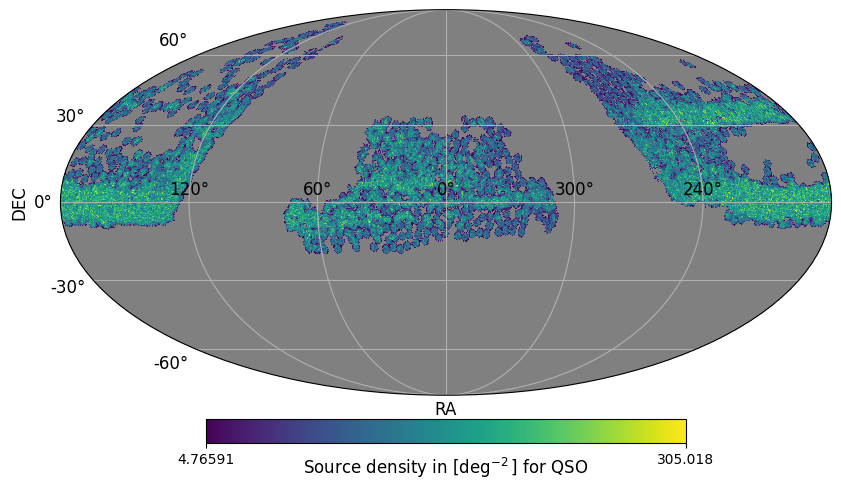

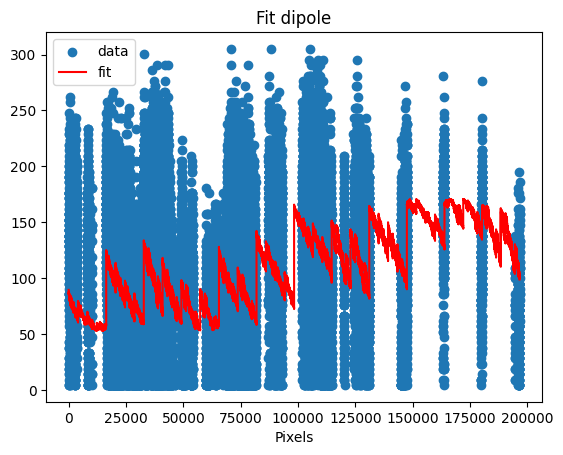

In [5]:
init =  (300, 1, 100, -10)
m = ALL_Mapper.fit_dipole("Masked", init, weights=DR1_Mapper.FRACCOVnside)
m

### From simulation

Total number of sources in the entire sky : 12386304
Theorical number of sources in one pixel : 63


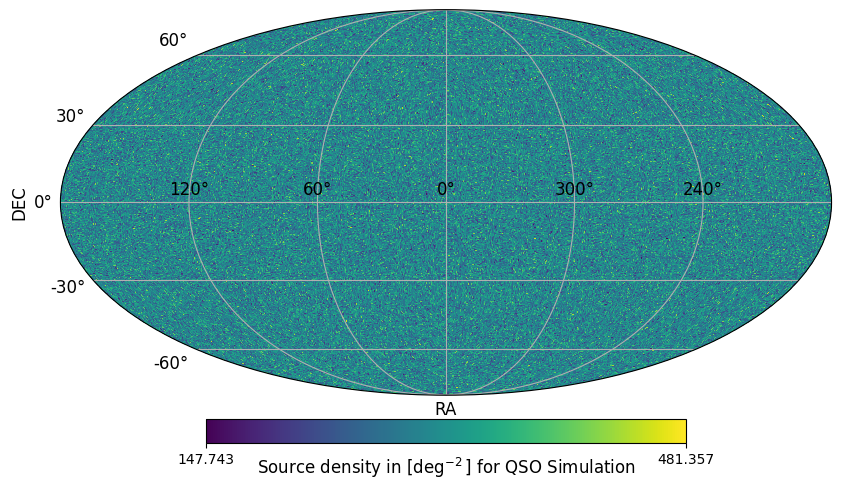

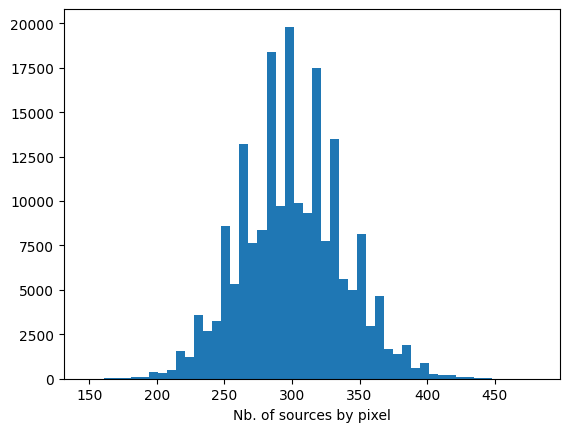

In [7]:
NSource_px_th = int(ALL_Mapper.map.max() * ALL_Mapper.area_deg2)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

#data = generate_lumMag(NSource_px_th*npix, to_table=True)
data = {}
data["RA"], data["DEC"] = generate_raDec(NSource_px_th*npix)
data = Table(data)

simu_Mapper = DensityMapper(data, nside=nside)
simu_Mapper._set_suffixTextPlot(unit = f"{sources} Simulation") #to customize the unit of plots.
simu_Mapper.plot('')

get_hist(simu_Mapper.map, bins=50);

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.333e+05 (χ²/ndof = 1.2)  │             Nfcn = 1107              │
│ EDM = 0.000296 (Goal: 0.0002)    │           time = 37.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  295.43   │   0.10    │   -0.10    │    0.10    │    0    │         │       │
│ 1 │ A    │  1.5e-3   │  0.5e-3   │  -0.4e-3   │   0.5e-3   │    0    │    1    │       │
│ 2 │ ra   │    328    │    18     │    -17     │     19     │    0    │   360   │       │
│ 3 │ dec  │    10     │    34     │    -36     │     30     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.1    │    0.1    │  -0.4e-3  │  0.5e-3   │    -17    │    19     │    -36    │    30     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │          N*           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│  N* │      0.0104   -11.03e-6      -0.206      -2.263 │
│   A │   -11.03e-6    2.06e-07 -1.16093e-3  5.38142e-3 │
│  ra │      -0.206 -1.16093e-3         321      0.17e3 │
│ dec │      -2.263  5.38142e-3      0.17e3    1.22e+03 │
└─────┴─────────────────────────────────────────────────┘

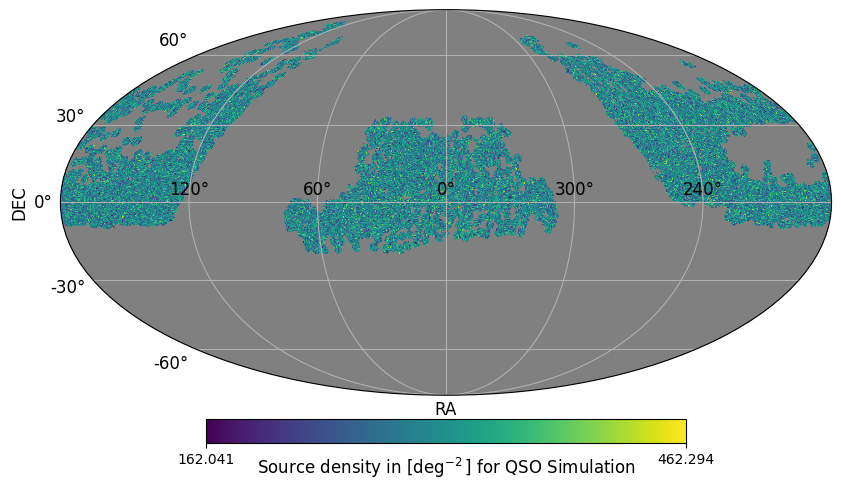

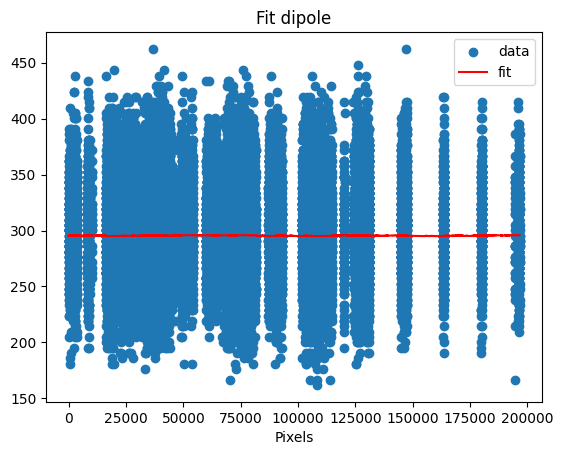

In [11]:
simu_Mapper.set_mask(mask=ALL_Mapper.mapMasked.mask)

init =  (200, 0, 100, -10)
m = simu_Mapper.fit_dipole("Masked", init)
m

Saving DESI_DR1_QSO_Simul_UniformMap_mask0 in data/Data DESI/DESI Figures/DESI DR1 QSO/DESI_DR1_QSO_Simul/DESI_DR1_QSO_Simul_UniformMap_mask0.pdf


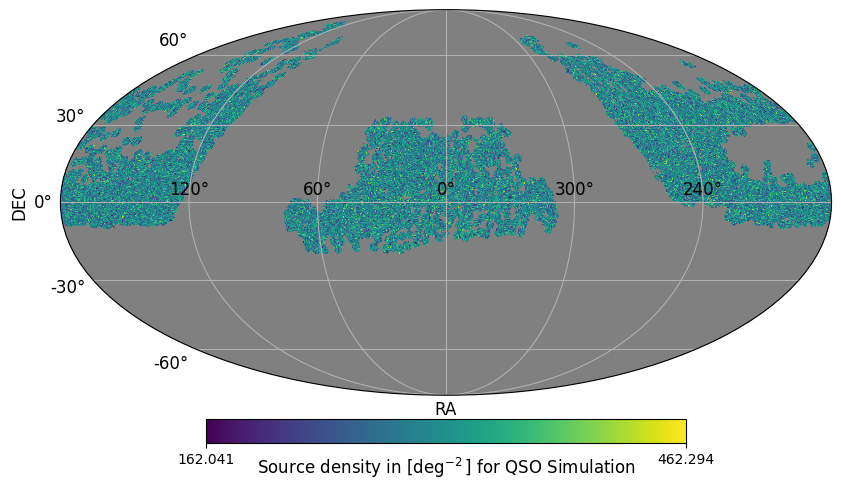

In [36]:
simu_Mapper.plot('Masked')
#get_savefig(plt, output_path_Simu, "DESI_DR1_QSO_Simul_UniformMap_mask0");

### FRACCOV rescaling

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.179e+06 (χ²/ndof = 21.3) │              Nfcn = 302              │
│ EDM = 5.42e-05 (Goal: 0.0002)    │            time = 9.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │   48.19   │   0.04    │   -0.04    │    0.04    │    0    │         │       │
│ 1 │ A    │  0.8292   │  0.0014   │  -0.0014   │   0.0014   │    0    │    1    │       │
│ 2 │ ra   │  194.73   │   0.22    │   -0.22    │    0.22    │    0    │   360   │       │
│ 3 │ dec  │  -69.28   │   0.05    │   -0.05    │    0.05    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.04   │   0.04    │  -0.0014  │  0.0014   │   -0.22   │   0.22    │   -0.05   │   0.05    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │  0.00157  27.7e-6  -0.0004  -0.0005 │
│   A │  27.7e-6 2.07e-06   5.9e-6 -11.9e-6 │
│  ra │  -0.0004   5.9e-6   0.0478   0.0027 │
│ dec │  -0.0005 -11.9e-6   0.0027   0.0029 │
└─────┴─────────────────────────────────────┘

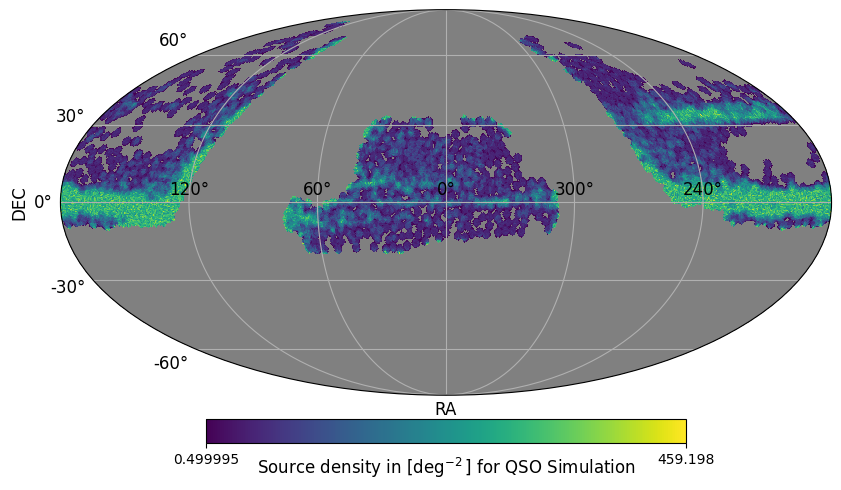

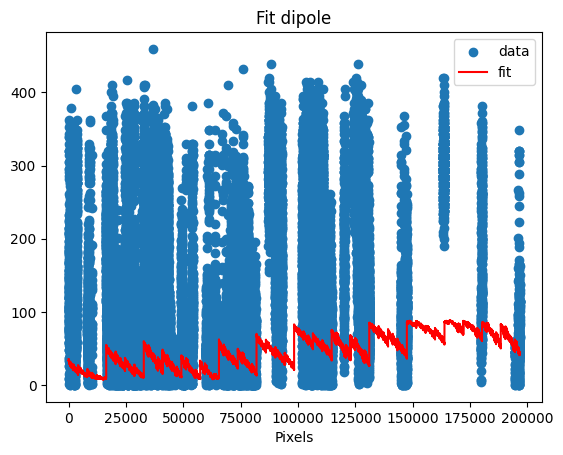

In [12]:
hpmap = simu_Mapper.map * DR1_Mapper.FRACCOVnside.filled(0)
hpmap[np.isnan(hpmap)] = 0
simu_Mapper_scale = DensityMapper.from_map(hpmap)
simu_Mapper_scale._set_suffixTextPlot(unit = f"{sources} Simulation") #to customize the unit of plots.
simu_Mapper_scale.set_mask()
# simu_Mapper_scale.plot("Masked")
# get_savefig(plt, output_path_Simu, suffix_Simu+"mask0");

init =  (300, 0, 100, -10)
m = simu_Mapper_scale.fit_dipole("Masked", init)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.166e+06 (χ²/ndof = 5.9)  │              Nfcn = 351              │
│ EDM = 0.000143 (Goal: 0.0002)    │           time = 11.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  146.49   │   0.10    │   -0.10    │    0.10    │    0    │         │       │
│ 1 │ A    │  0.8774   │  0.0014   │  -0.0014   │   0.0014   │    0    │    1    │       │
│ 2 │ ra   │  185.47   │   0.15    │   -0.15    │    0.15    │    0    │   360   │       │
│ 3 │ dec  │  -66.02   │   0.06    │   -0.06    │    0.06    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.1    │    0.1    │  -0.0014  │  0.0014   │   -0.15   │   0.15    │   -0.06   │   0.06    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │  0.00987  46.4e-6    0.001  -0.0025 │
│   A │  46.4e-6 2.02e-06  27.8e-6 -33.5e-6 │
│  ra │    0.001  27.8e-6   0.0233  -0.0011 │
│ dec │  -0.0025 -33.5e-6  -0.0011  0.00312 │
└─────┴─────────────────────────────────────┘

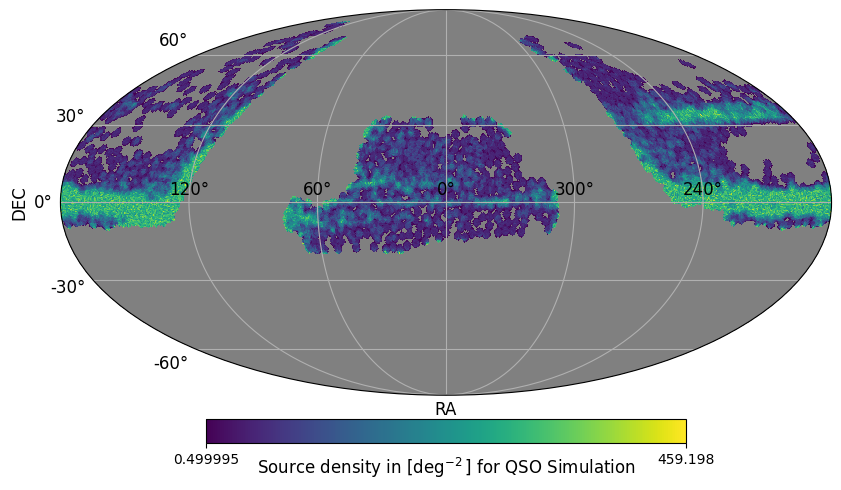

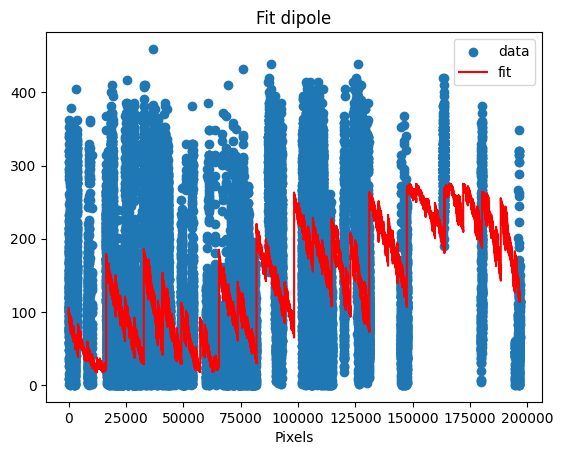

In [13]:
init =  (300, 0, 100, -10)
m = simu_Mapper_scale.fit_dipole("Masked", init, weights=DR1_Mapper.FRACCOVnside)
m

### From Poisson noise

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.18e+06 (χ²/ndof = 21.3)  │              Nfcn = 497              │
│ EDM = 1.17e-05 (Goal: 0.0002)    │           time = 15.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │   48.20   │   0.04    │   -0.04    │    0.04    │    0    │         │       │
│ 1 │ A    │  0.8343   │  0.0014   │  -0.0014   │   0.0014   │    0    │    1    │       │
│ 2 │ ra   │  194.41   │   0.21    │   -0.21    │    0.21    │    0    │   360   │       │
│ 3 │ dec  │  -68.83   │   0.05    │   -0.05    │    0.05    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.04   │   0.04    │  -0.0014  │  0.0014   │   -0.21   │   0.21    │   -0.05   │   0.05    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │  0.00157  27.6e-6  -0.0004  -0.0005 │
│   A │  27.6e-6 2.05e-06   8.7e-6 -13.1e-6 │
│  ra │  -0.0004   8.7e-6   0.0454   0.0026 │
│ dec │  -0.0005 -13.1e-6   0.0026  0.00287 │
└─────┴─────────────────────────────────────┘

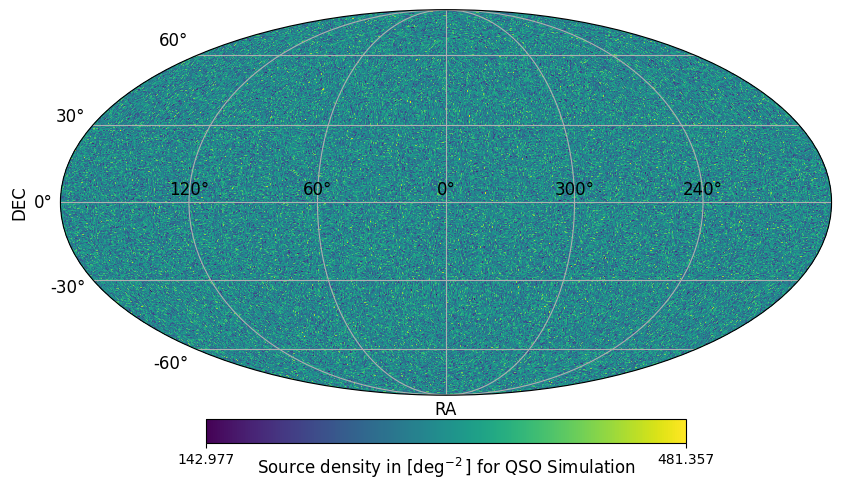

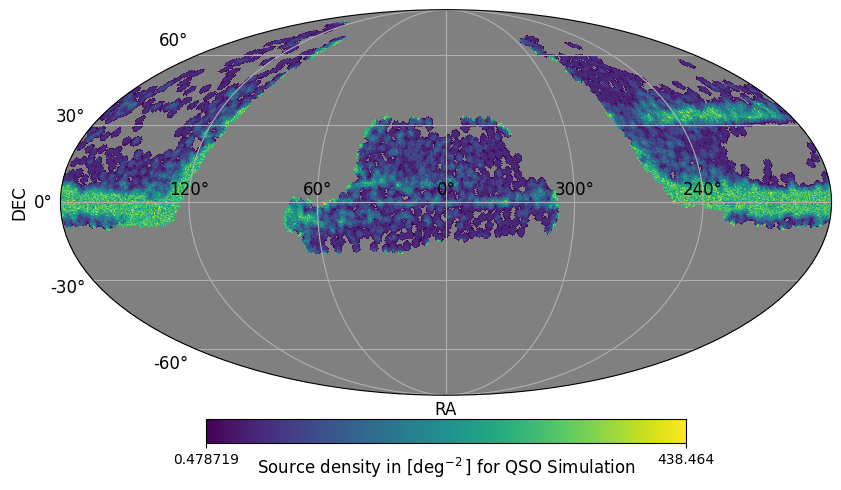

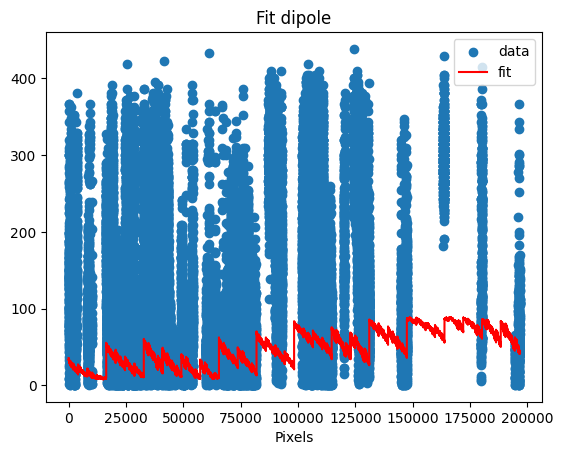

In [13]:
hpmap = np.random.poisson(NSource_px_th, npix)/area_deg2
simu_Mapper_pois = DensityMapper.from_map(hpmap)
simu_Mapper_pois._set_suffixTextPlot(unit = f"{sources} Simulation") #to customize the unit of plots.
simu_Mapper_pois.plot('')

hpmap = simu_Mapper_pois.map * DR1_Mapper.FRACCOVnside.filled(0)
hpmap[np.isnan(hpmap)] = 0
simu_Mapper_pois = DensityMapper.from_map(hpmap)
simu_Mapper_pois._set_suffixTextPlot(unit = f"{sources} Simulation") #to customize the unit of plots.
simu_Mapper_pois.set_mask()

init =  (200, 0, 100, -10)
m = simu_Mapper_pois.fit_dipole("Masked", init)
m

## FRACCOV cut

### From DESI data

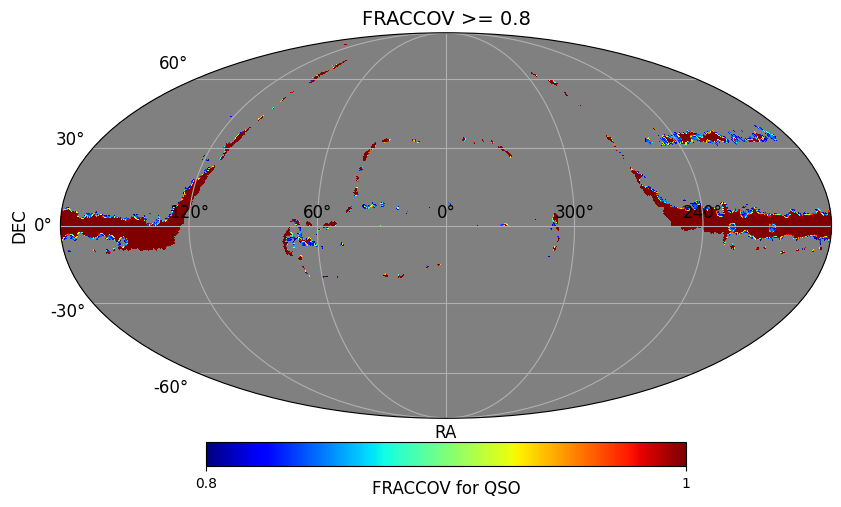

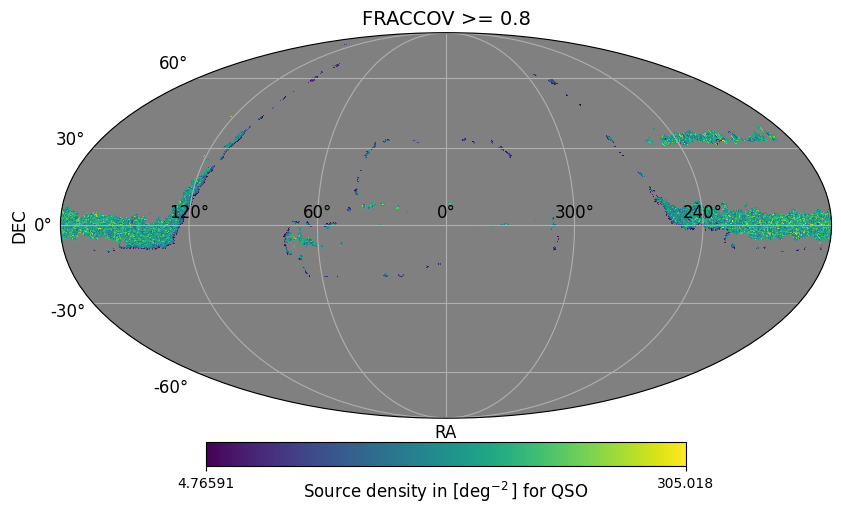

In [14]:
frac_min = 0.8
title = f'FRACCOV >= {frac_min}'

DR1_Mapper.cut_FracCov(frac_min=frac_min)
DR1_Mapper.plot(use_map="cut", title=title)

ALL_Mapper.set_cutMask(DR1_Mapper.FRACCOVcut.mask)
ALL_Mapper.plot(use_map='Cut', title=title)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.799e+05 (χ²/ndof = 1.4)  │              Nfcn = 321              │
│ EDM = 3.65e-05 (Goal: 0.0002)    │            time = 9.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │   84.69   │   0.18    │   -0.18    │    0.18    │    0    │         │       │
│ 1 │ A    │   0.911   │   0.004   │   -0.004   │   0.004    │    0    │    1    │       │
│ 2 │ ra   │  191.39   │   0.15    │   -0.15    │    0.15    │    0    │   360   │       │
│ 3 │ dec  │   -17.7   │    0.4    │    -0.4    │    0.4     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.18   │   0.18    │  -0.004   │   0.004   │   -0.15   │   0.15    │   -0.4    │    0.4    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────┐
│     │        N*         A        ra       dec │
├─────┼─────────────────────────────────────────┤
│  N* │    0.0336 -0.536e-3     0.010    -0.037 │
│   A │ -0.536e-3  1.52e-05 -0.159e-3  0.172e-3 │
│  ra │     0.010 -0.159e-3    0.0219    -0.013 │
│ dec │    -0.037  0.172e-3    -0.013     0.127 │
└─────┴─────────────────────────────────────────┘

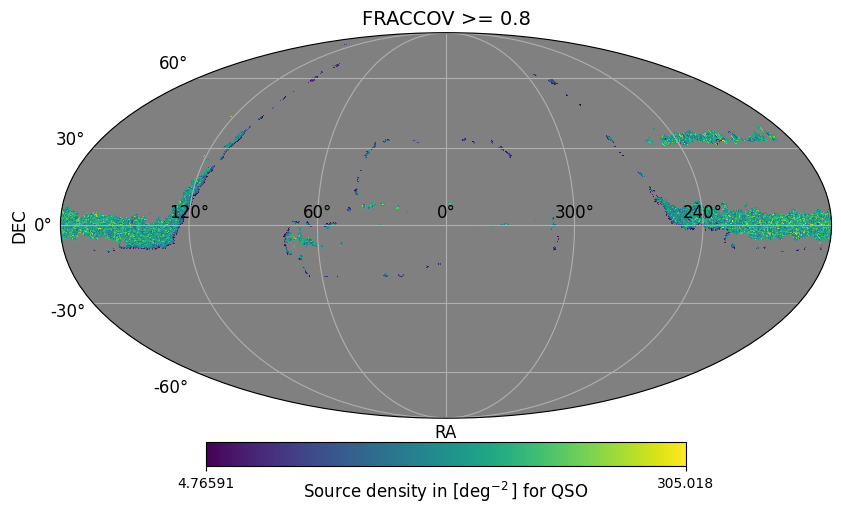

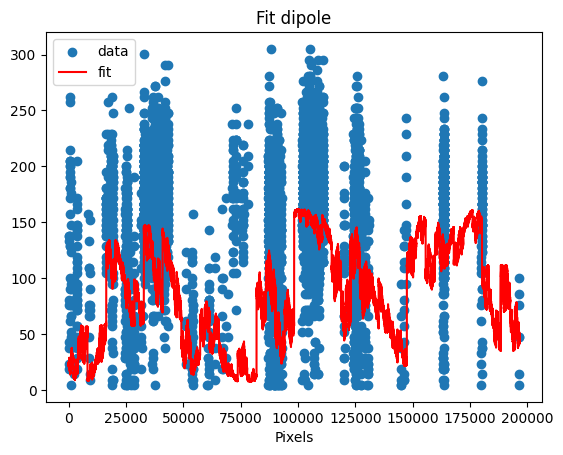

In [18]:
init =  (100, 0, 100, -10)
m = ALL_Mapper.fit_dipole("Cut", init, title_map=title, weights=DR1_Mapper.FRACCOVnside)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.895e+05 (χ²/ndof = 1.5)  │              Nfcn = 343              │
│ EDM = 6.89e-06 (Goal: 0.0002)    │           time = 12.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │   86.33   │   0.18    │   -0.18    │    0.18    │    0    │         │       │
│ 1 │ A    │   0.877   │   0.004   │   -0.004   │   0.004    │    0    │    1    │       │
│ 2 │ ra   │  191.43   │   0.15    │   -0.15    │    0.15    │    0    │   360   │       │
│ 3 │ dec  │   -18.3   │    0.4    │    -0.4    │    0.4     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.18   │   0.18    │  -0.004   │   0.004   │   -0.15   │   0.15    │   -0.4    │    0.4    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────┐
│     │        N*         A        ra       dec │
├─────┼─────────────────────────────────────────┤
│  N* │    0.0325 -0.490e-3     0.010    -0.037 │
│   A │ -0.490e-3  1.38e-05 -0.148e-3  0.132e-3 │
│  ra │     0.010 -0.148e-3    0.0224    -0.013 │
│ dec │    -0.037  0.132e-3    -0.013     0.126 │
└─────┴─────────────────────────────────────────┘

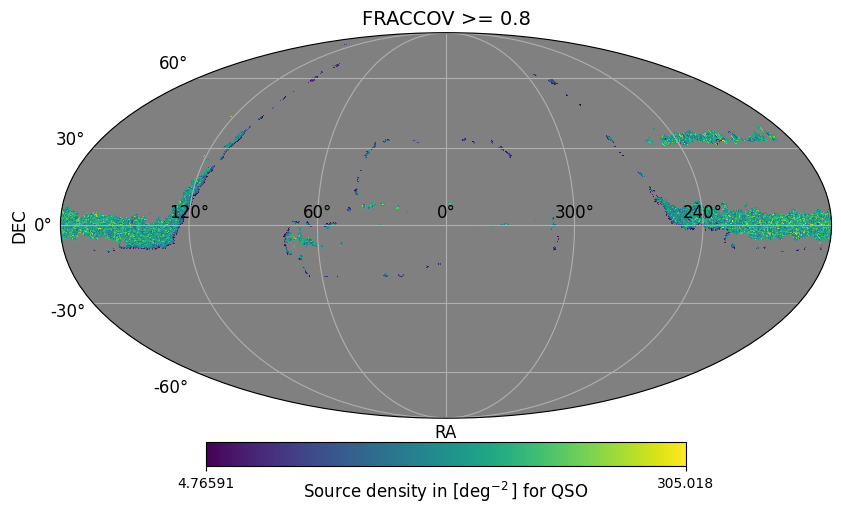

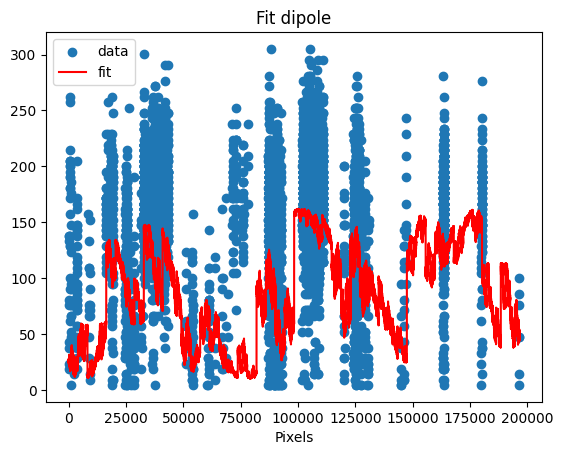

In [19]:
init =  (100, 0, 100, -10)
m = ALL_Mapper.fit_dipole("Cut", init, title_map=title)
m

### From simulation

Attribut FRACCOVcut already existed and has been replaced.


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5.153e+04 (χ²/ndof = 0.3)  │              Nfcn = 525              │
│ EDM = 3.72e-06 (Goal: 0.0002)    │           time = 18.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  284.27   │   0.33    │   -0.33    │    0.33    │    0    │         │       │
│ 1 │ A    │  0.0416   │  0.0027   │  -0.0026   │   0.0027   │    0    │    1    │       │
│ 2 │ ra   │   172.7   │    3.3    │    -3.3    │    3.4     │    0    │   360   │       │
│ 3 │ dec  │   -65.4   │    2.9    │    -2.8    │    3.1     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.33   │   0.33    │  -0.0026  │  0.0027   │   -3.4    │    3.4    │   -2.8    │    3.1    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────┐
│     │        N*         A        ra       dec │
├─────┼─────────────────────────────────────────┤
│  N* │      0.11    242e-6     -0.06     -0.76 │
│   A │    242e-6  7.07e-06  1.279e-3 -4.910e-3 │
│  ra │     -0.06  1.279e-3      11.2        -1 │
│ dec │     -0.76 -4.910e-3        -1      8.58 │
└─────┴─────────────────────────────────────────┘

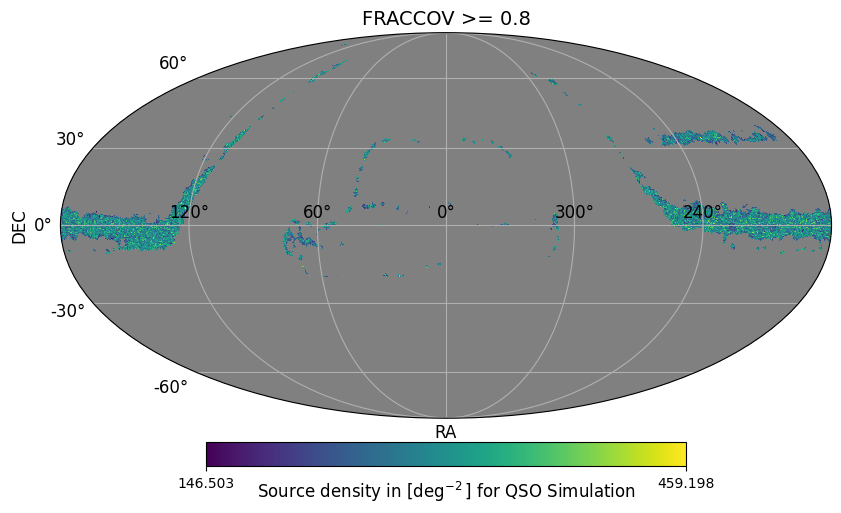

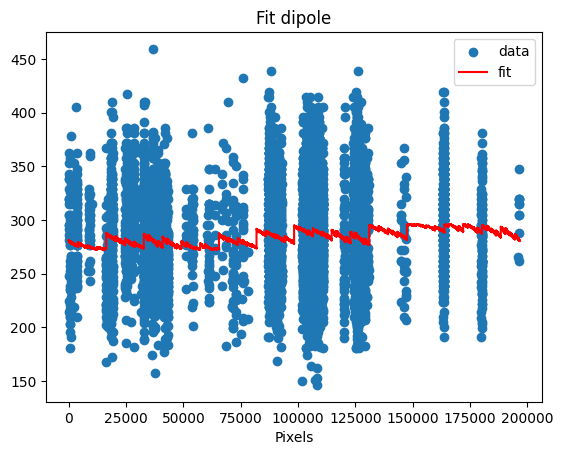

In [20]:
frac_min = 0.8
title = f'FRACCOV >= {frac_min}'
DR1_Mapper.cut_FracCov(frac_min=frac_min)
simu_Mapper_scale.set_cutMask(DR1_Mapper.FRACCOVcut.mask)

init =  (300, 0, 100, -10)
m = simu_Mapper_scale.fit_dipole("Cut", init, title_map=title, weights=DR1_Mapper.FRACCOVnside)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5.414e+04 (χ²/ndof = 0.3)  │              Nfcn = 548              │
│ EDM = 2.03e-05 (Goal: 0.0002)    │           time = 18.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  282.79   │   0.32    │   -0.32    │    0.32    │    0    │         │       │
│ 1 │ A    │  0.0452   │  0.0026   │  -0.0026   │   0.0026   │    0    │    1    │       │
│ 2 │ ra   │   173.3   │    2.9    │    -2.9    │    2.9     │    0    │   360   │       │
│ 3 │ dec  │   -64.4   │    2.7    │    -2.6    │    2.8     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.32   │   0.32    │  -0.0026  │  0.0026   │   -2.9    │    2.9    │   -2.6    │    2.8    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────┐
│     │        N*         A        ra       dec │
├─────┼─────────────────────────────────────────┤
│  N* │     0.103    215e-6     -0.03     -0.66 │
│   A │    215e-6   6.6e-06  1.174e-3 -4.290e-3 │
│  ra │     -0.03  1.174e-3      8.58        -1 │
│ dec │     -0.66 -4.290e-3        -1      7.06 │
└─────┴─────────────────────────────────────────┘

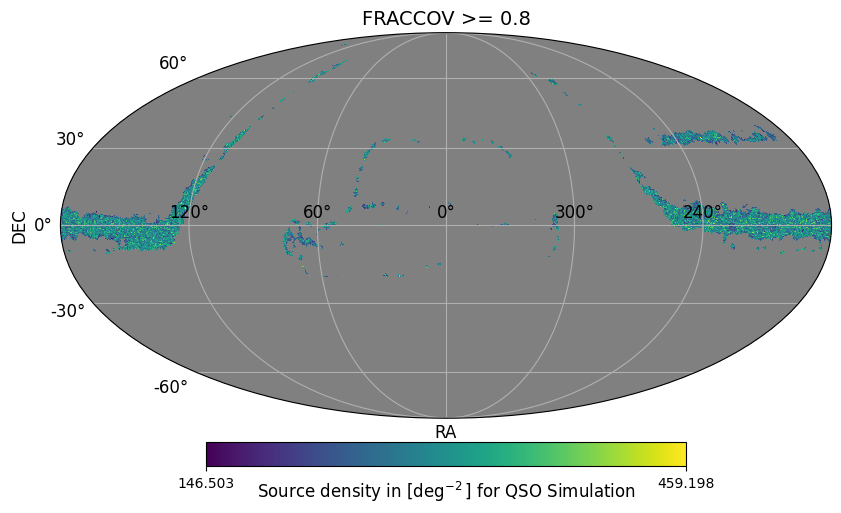

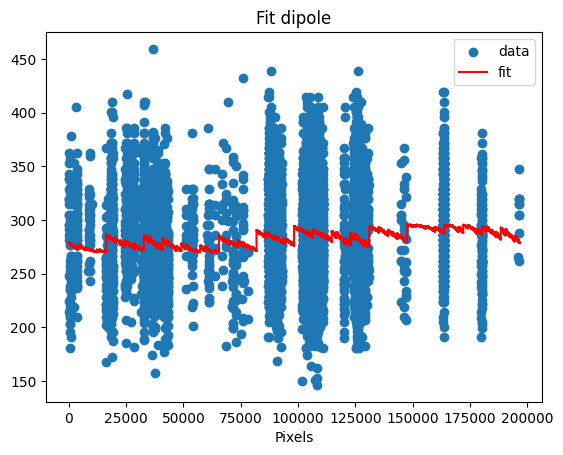

In [21]:
init =  (300, 0, 100, -10)
m = simu_Mapper_scale.fit_dipole("Cut", init, title_map=title)
m

## Density count > min and FRACCOV > frac_min

### From DESI data

Attribut FRACCOVcut already existed and has been replaced.
Attribut map has no attribut mask. Using mask from mapMasked instead.
Attribut mapCut already existed and has been replaced.
Attribut mapCut already existed and has been replaced.


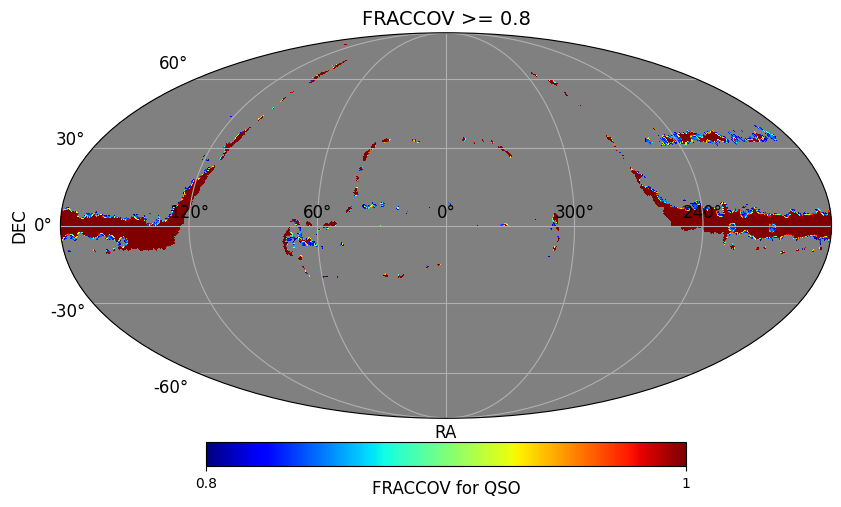

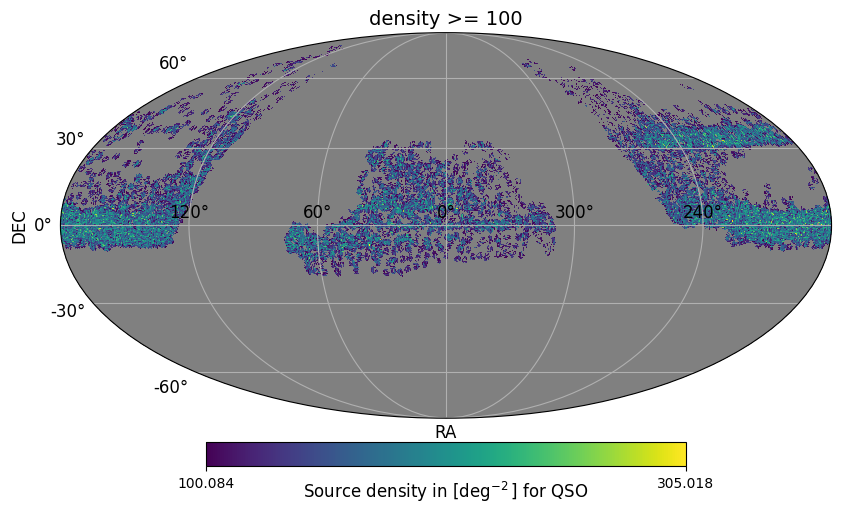

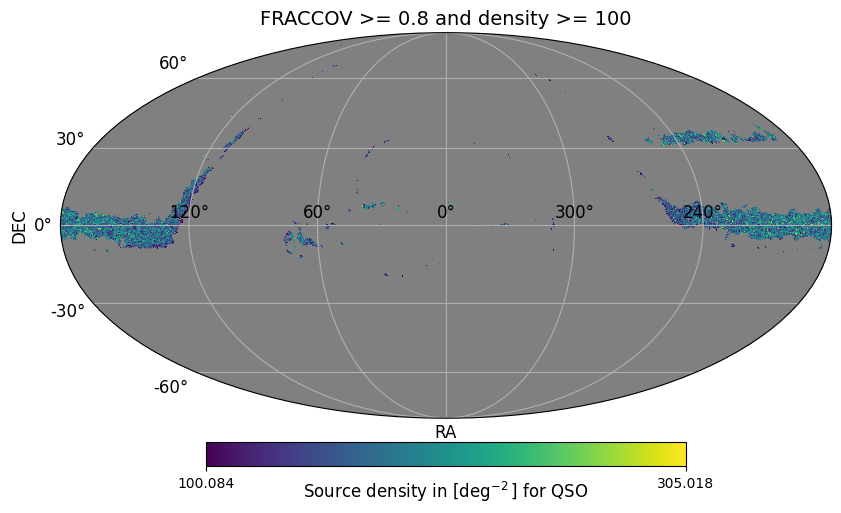

In [22]:
frac_min = 0.8
DR1_Mapper.cut_FracCov(frac_min=frac_min)
DR1_Mapper.plot(use_map="cut", title = f"FRACCOV >= {frac_min}")

count_min = 100
ALL_Mapper.select_bounds(map_min=count_min)
ALL_Mapper.plot(use_map="Cut", title = f"density >= {count_min}")

title = f'FRACCOV >= {frac_min} and density >= {count_min}'
ALL_Mapper.set_cutMask(DR1_Mapper.FRACCOVcut.mask, fromMap="Cut")
ALL_Mapper.plot(use_map="Cut", title=title)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.839e+04 (χ²/ndof = 0.2)  │              Nfcn = 476              │
│ EDM = 3.01e-05 (Goal: 0.0002)    │           time = 15.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  154.93   │   0.33    │   -0.33    │    0.33    │    0    │         │       │
│ 1 │ A    │  0.1174   │  0.0028   │  -0.0028   │   0.0028   │    0    │    1    │       │
│ 2 │ ra   │   189.1   │    0.8    │    -0.8    │    0.8     │    0    │   360   │       │
│ 3 │ dec  │   -6.3    │    2.6    │    -2.6    │    2.6     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.33   │   0.33    │  -0.0028  │  0.0028   │   -0.8    │    0.8    │   -2.6    │    2.6    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │     0.11  -769e-6     0.09    -0.36 │
│   A │  -769e-6 7.68e-06  -530e-6   642e-6 │
│  ra │     0.09  -530e-6    0.694     -0.6 │
│ dec │    -0.36   642e-6     -0.6     6.65 │
└─────┴─────────────────────────────────────┘

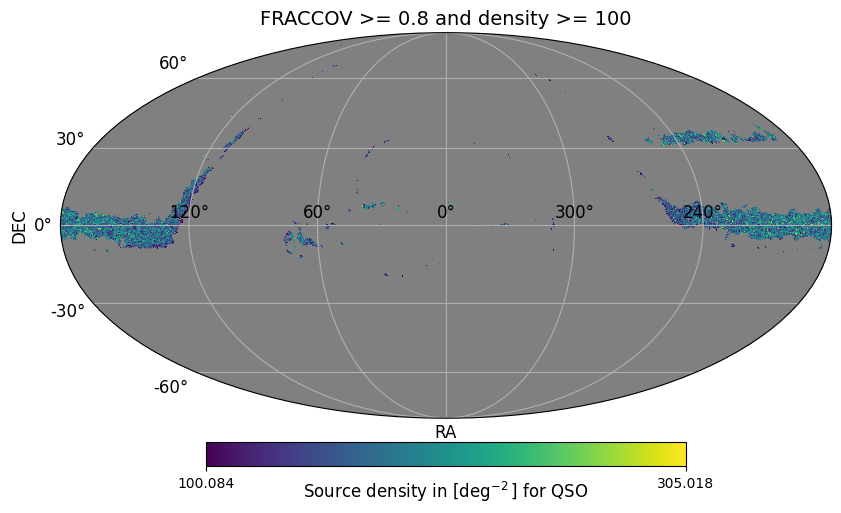

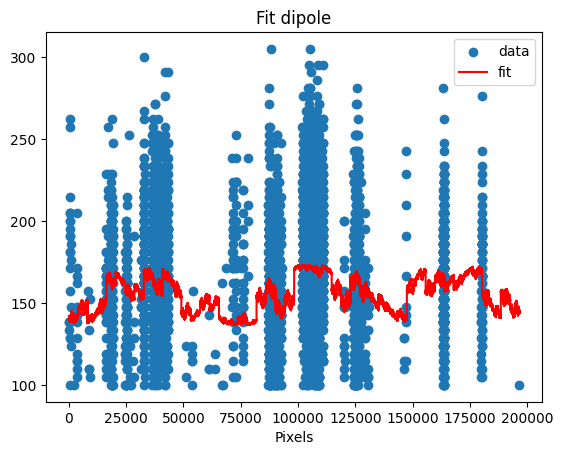

In [23]:
init =  (100, 0, 100, -10)
m = ALL_Mapper.fit_dipole("Cut", init, title_map=title, weights=DR1_Mapper.FRACCOVnside)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5.019e+04 (χ²/ndof = 0.3)  │              Nfcn = 543              │
│ EDM = 9.89e-07 (Goal: 0.0002)    │           time = 19.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  155.66   │   0.32    │   -0.32    │    0.32    │    0    │         │       │
│ 1 │ A    │  0.1114   │  0.0026   │  -0.0026   │   0.0026   │    0    │    1    │       │
│ 2 │ ra   │   189.1   │    0.9    │    -0.9    │    0.9     │    0    │   360   │       │
│ 3 │ dec  │   -7.1    │    2.6    │    -2.6    │    2.6     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.32   │   0.32    │  -0.0026  │  0.0026   │   -0.9    │    0.9    │   -2.6    │    2.6    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │    0.101  -681e-6     0.09    -0.36 │
│   A │  -681e-6 6.91e-06  -494e-6   397e-6 │
│  ra │     0.09  -494e-6    0.744     -0.7 │
│ dec │    -0.36   397e-6     -0.7     6.88 │
└─────┴─────────────────────────────────────┘

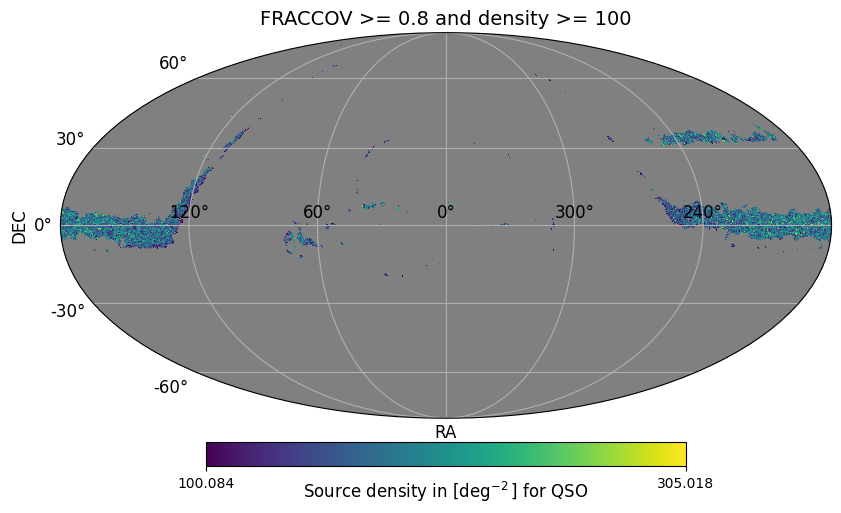

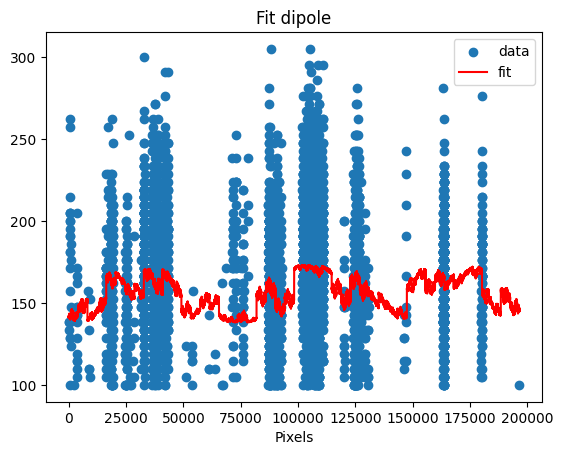

In [24]:
init =  (100, 0, 100, -10)
m = ALL_Mapper.fit_dipole("Cut", init, title_map=title)
m

### From simulation

Attribut FRACCOVcut already existed and has been replaced.
Attribut map has no attribut mask. Using mask from mapMasked instead.
Attribut mapCut already existed and has been replaced.
Attribut mapCut already existed and has been replaced.


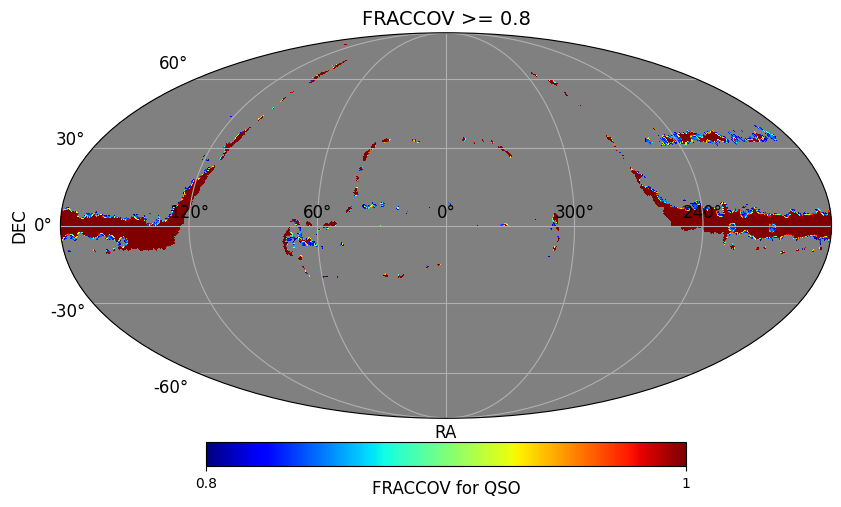

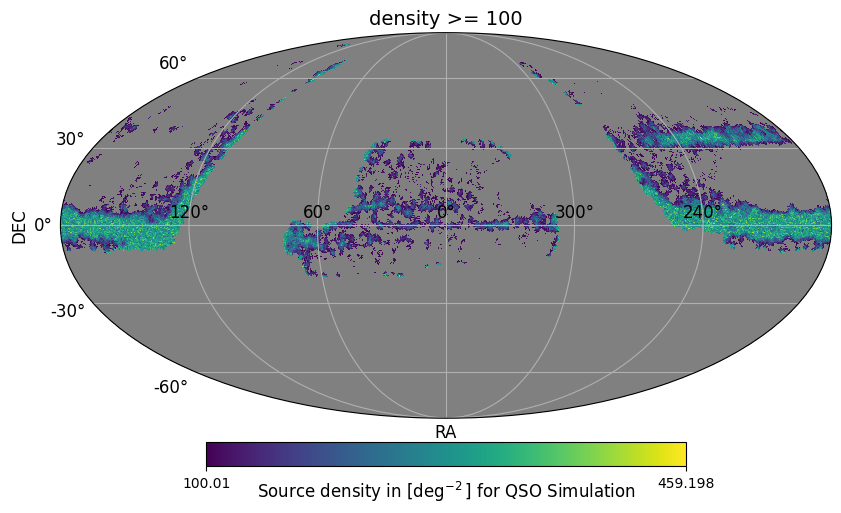

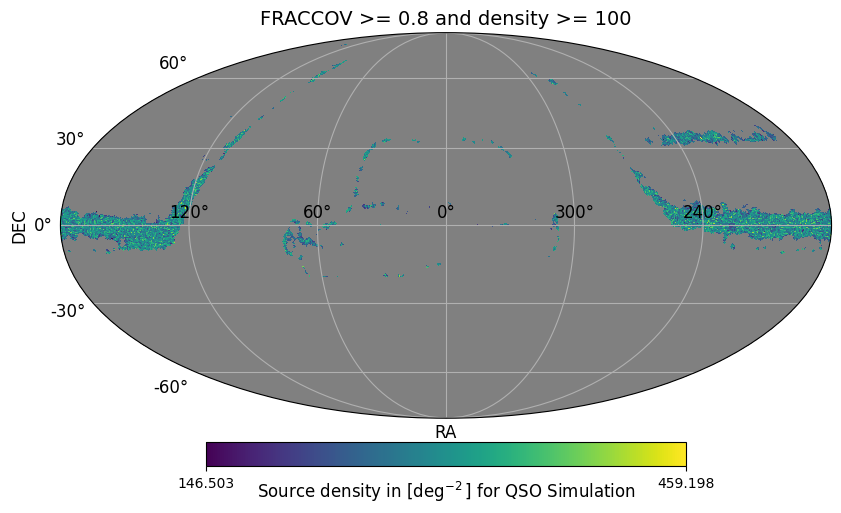

In [25]:
frac_min = 0.8
DR1_Mapper.cut_FracCov(frac_min=frac_min)
DR1_Mapper.plot(use_map="cut", title = f"FRACCOV >= {frac_min}")

count_min = 100
simu_Mapper_scale.select_bounds(map_min=count_min)
simu_Mapper_scale.plot(use_map="Cut", title = f"density >= {count_min}")

title = f'FRACCOV >= {frac_min} and density >= {count_min}'
simu_Mapper_scale.set_cutMask(DR1_Mapper.FRACCOVcut.mask, fromMap="Cut")
simu_Mapper_scale.plot(use_map="Cut", title=title)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5.153e+04 (χ²/ndof = 0.3)  │              Nfcn = 946              │
│ EDM = 8.8e-05 (Goal: 0.0002)     │           time = 32.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  284.27   │   0.33    │   -0.33    │    0.33    │    0    │         │       │
│ 1 │ A    │  0.0417   │  0.0026   │  -0.0027   │   0.0027   │    0    │    1    │       │
│ 2 │ ra   │   172.7   │    3.3    │    -3.3    │    3.4     │    0    │   360   │       │
│ 3 │ dec  │   -65.4   │    2.9    │    -2.8    │    3.1     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.33   │   0.33    │  -0.0027  │  0.0027   │   -3.3    │    3.4    │   -2.8    │    3.1    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────┐
│     │        N*         A        ra       dec │
├─────┼─────────────────────────────────────────┤
│  N* │     0.108    222e-6     -0.06     -0.74 │
│   A │    222e-6  6.86e-06  1.233e-3 -4.655e-3 │
│  ra │     -0.06  1.233e-3      11.1        -1 │
│ dec │     -0.74 -4.655e-3        -1      8.31 │
└─────┴─────────────────────────────────────────┘

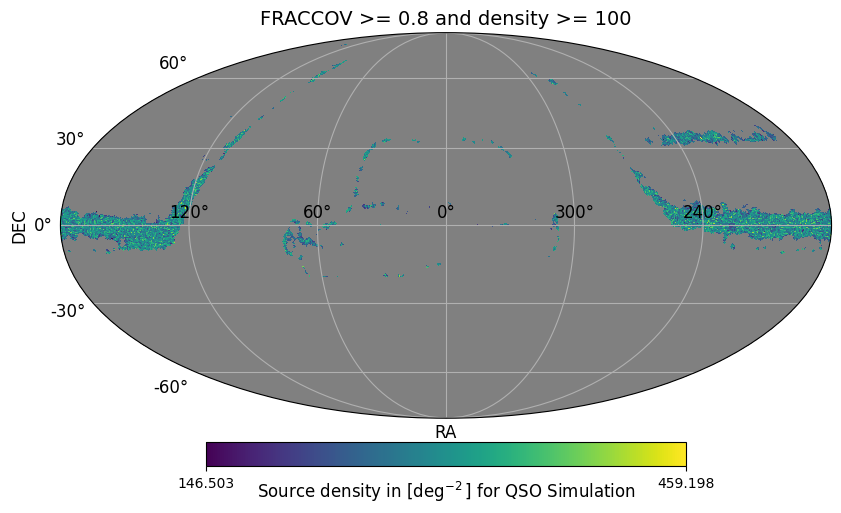

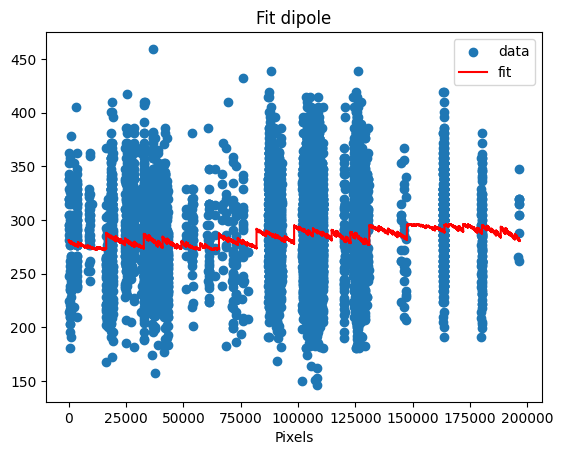

In [28]:
init =  (100, 0, 100, -10)
m = simu_Mapper_scale.fit_dipole("Cut", init, title_map=title, weights=DR1_Mapper.FRACCOVnside)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5.414e+04 (χ²/ndof = 0.3)  │              Nfcn = 783              │
│ EDM = 3.21e-06 (Goal: 0.0002)    │           time = 26.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  282.79   │   0.32    │   -0.32    │    0.32    │    0    │         │       │
│ 1 │ A    │  0.0452   │  0.0026   │  -0.0026   │   0.0026   │    0    │    1    │       │
│ 2 │ ra   │   173.3   │    2.9    │    -2.9    │    2.9     │    0    │   360   │       │
│ 3 │ dec  │   -64.4   │    2.7    │    -2.6    │    2.8     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.32   │   0.32    │  -0.0026  │  0.0026   │   -2.9    │    2.9    │   -2.6    │    2.8    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────┐
│     │        N*         A        ra       dec │
├─────┼─────────────────────────────────────────┤
│  N* │     0.103    213e-6     -0.02     -0.66 │
│   A │    213e-6  6.58e-06  1.171e-3 -4.267e-3 │
│  ra │     -0.02  1.171e-3      8.58        -1 │
│ dec │     -0.66 -4.267e-3        -1      7.03 │
└─────┴─────────────────────────────────────────┘

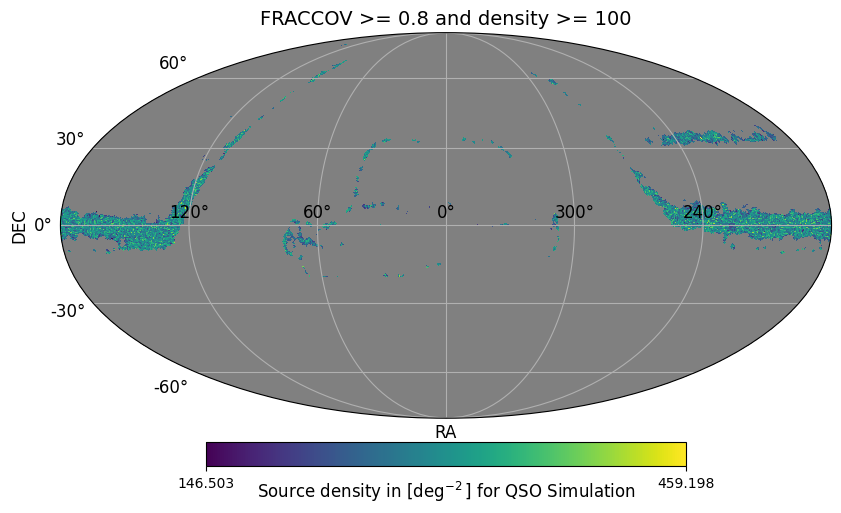

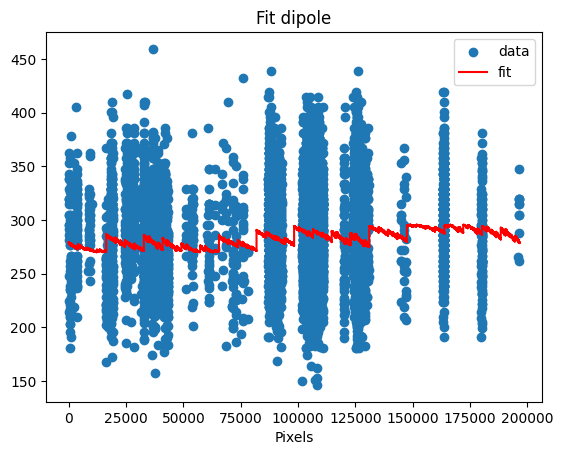

In [27]:
init =  (200, 0, 100, -10)
m = simu_Mapper_scale.fit_dipole("Cut", init, title_map=title)
m

## Introducing clustering

In [27]:
DIRcl = "Simulation/Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "zmin0.1"
FILEcl = DIRcl + sufix + '.fits'

data = fitsio.FITS(FILEcl)
data


  file: Simulation/Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_tests_fit.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      MAPS
  2      BINARY_TBL      FIT_NUMPY
  3      BINARY_TBL      FIT_MINUIT

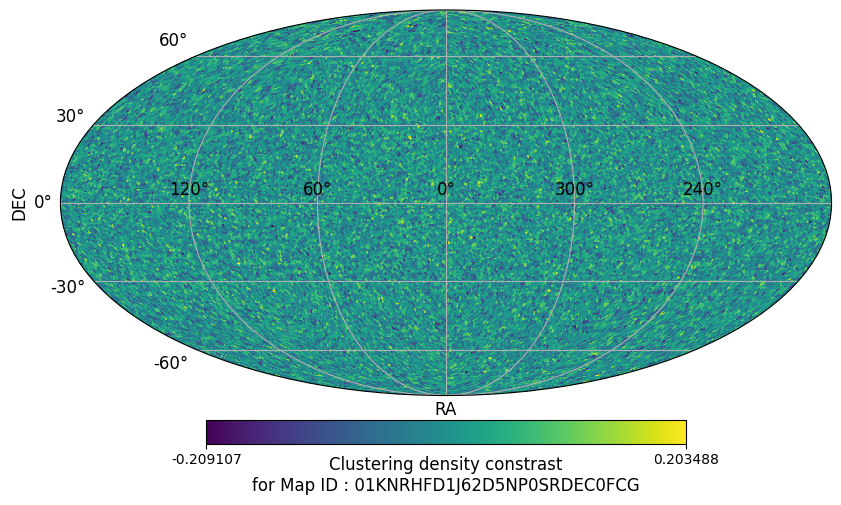

In [28]:
from Simulation.mappers import CountMapper

mapID, hpmap = data['MAPS'][0] #first clustering map
hpmap = hp.reorder(hpmap, r2n=True)
clMapper = CountMapper.from_map(hpmap)
clMapper._set_instance_settingsPlot(unit = f"Clustering density constrast\nfor Map ID : {mapID}")
clMapper.plot()

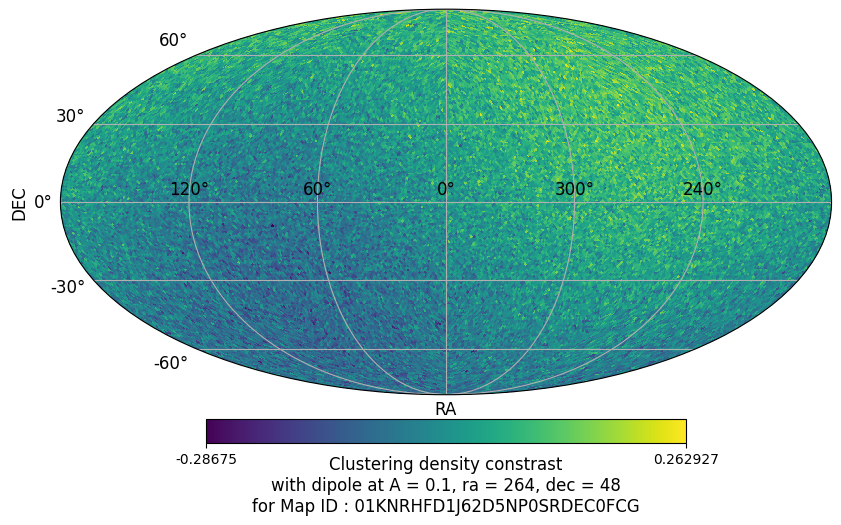

In [29]:
A, ra, dec = 0.1, 264, 48
clDipole = apply_dipole_MD(clMapper.map, clMapper.map, A, ra, dec, nest=True)
clDipoleMapper = CountMapper.from_map(clDipole)
clDipoleMapper._set_instance_settingsPlot(unit = f"Clustering density constrast\nwith dipole at A = {A}, ra = {ra}, dec = {dec}\nfor Map ID : {mapID}")
clDipoleMapper.plot()

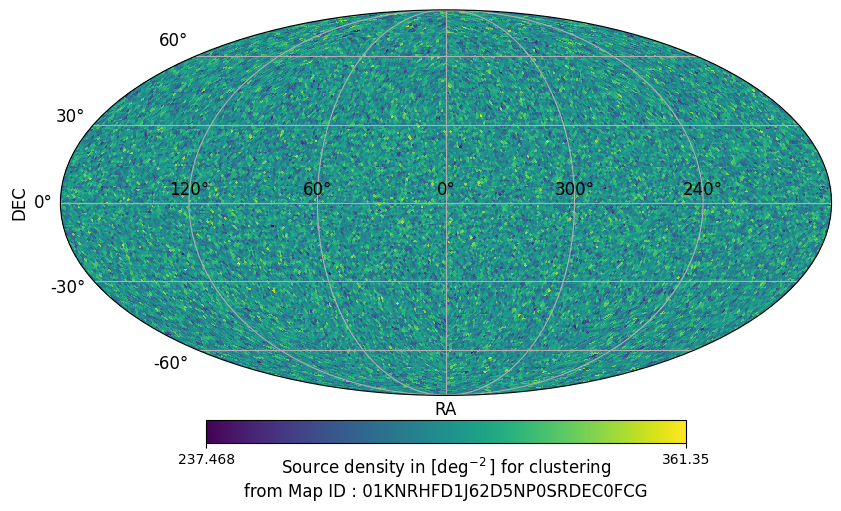

In [30]:
clMonop = apply_monopole_Mcontrast(clMapper.map, NSource_px_th/area_deg2)
clMonopMapper = DensityMapper.from_map(clMonop)
clMonopMapper._set_suffixTextPlot(unit = f"clustering\nfrom Map ID : {mapID}")
clMonopMapper.plot()

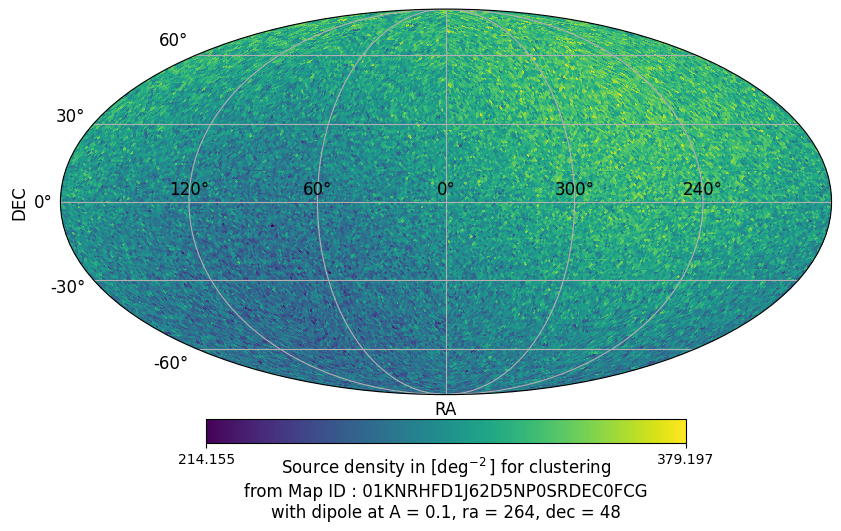

In [31]:
clDipMonop = apply_monopole_Mcontrast(clDipoleMapper.map, NSource_px_th/area_deg2)
clDipMonopMapper = DensityMapper.from_map(clDipMonop)
clDipMonopMapper._set_suffixTextPlot(unit = f"clustering\nfrom Map ID : {mapID}\nwith dipole at A = {A}, ra = {ra}, dec = {dec}")
clDipMonopMapper.plot()